# 📊 Multiple Linear Regression — Multi-Channel Marketing Analysis
### Predicting Sales from TV, Radio, Social Media & Influencer Spend
**Dataset:** 572 records | Predictors: TV (categorical), Radio, Social Media, Influencer | Target: Sales


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load & Preview Dataset

In [2]:
df = pd.read_csv('marketing_data_multi.csv')

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Columns: {list(df.columns)}")
print()
print("--- Data Types ---")
print(df.dtypes)
print()
df.head(10)


✅ Dataset loaded: 572 rows × 5 columns
   Columns: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

--- Data Types ---
TV                  str
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
dtype: object



,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377
5,Low,5.561586,3.530209,Nano,39.992087
6,Medium,13.951808,4.477142,Micro,147.150178
7,Medium,28.352592,4.695376,Mega,229.141912
8,Medium,15.322175,4.379750,Macro,222.696768
9,High,26.914287,6.074165,Mega,322.466797


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Missing values
print("--- Missing Values ---")
print(df.isnull().sum())
print()

# Descriptive stats (numeric only)
print("--- Descriptive Statistics (Numeric Columns) ---")
df.describe().round(2)


--- Missing Values ---
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

--- Descriptive Statistics (Numeric Columns) ---


,Radio,Social Media,Sales
count,572.00,572.00,572.00
mean,17.52,3.33,189.30
std,9.29,2.24,89.87
min,0.11,0.00,33.51
25%,10.70,1.59,118.72
50%,17.15,3.15,184.01
75%,24.61,4.73,264.50
max,42.27,11.40,357.79


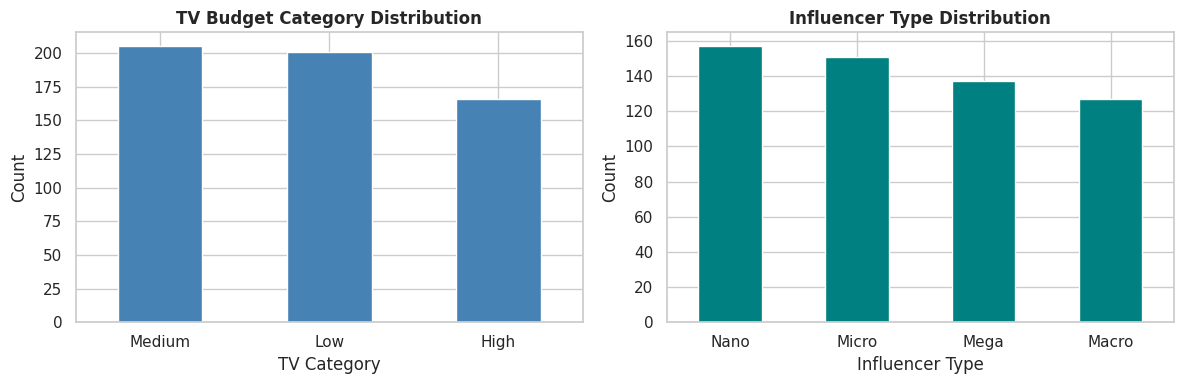

✅ Categorical distributions plotted!


In [4]:
# Categorical value counts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['TV'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('TV Budget Category Distribution', fontweight='bold')
axes[0].set_xlabel('TV Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Influencer'].value_counts().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Influencer Type Distribution', fontweight='bold')
axes[1].set_xlabel('Influencer Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('category_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Categorical distributions plotted!")


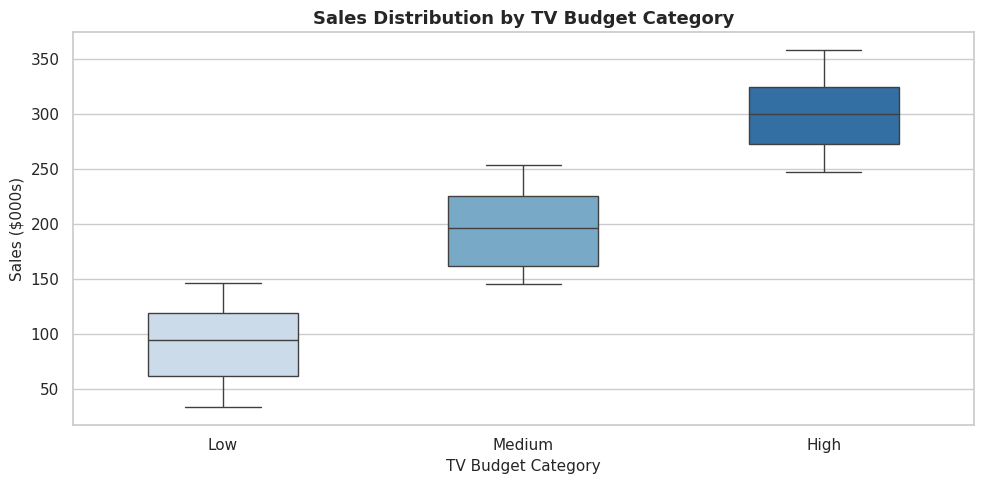

In [5]:
# Sales distribution by TV category
plt.figure(figsize=(10, 5))
order = ['Low', 'Medium', 'High']
sns.boxplot(x='TV', y='Sales', data=df, order=order,
            palette='Blues', width=0.5)
plt.title('Sales Distribution by TV Budget Category', fontsize=13, fontweight='bold')
plt.xlabel('TV Budget Category', fontsize=11)
plt.ylabel('Sales ($000s)', fontsize=11)
plt.tight_layout()
plt.savefig('sales_by_tv.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Encode Categorical Variables
TV and Influencer are categorical. We apply **one-hot encoding** (`pd.get_dummies` with `drop_first=True`)
to convert them into numeric dummy variables, avoiding the dummy variable trap.

- **TV reference category:** High (dropped)
- **Influencer reference category:** Macro (dropped)


In [6]:
# One-hot encode TV and Influencer
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True)

# Clean column names (replace spaces with underscores)
df_encoded.columns = [c.replace(' ', '_') for c in df_encoded.columns]

# Convert boolean dummy columns to integer (0/1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("✅ Encoding complete!")
print(f"   New shape: {df_encoded.shape[0]} rows × {df_encoded.shape[1]} columns")
print()
print("--- Encoded Columns ---")
print(list(df_encoded.columns))
print()
df_encoded.head()


✅ Encoding complete!
   New shape: 572 rows × 8 columns

--- Encoded Columns ---
['Radio', 'Social_Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']



,Radio,Social_Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,1,0,0,1,0
1,7.756876,2.572287,67.574904,1,0,1,0,0
2,20.348988,1.227180,272.250108,0,0,0,1,0
3,20.108487,2.728374,195.102176,0,1,1,0,0
4,31.653200,7.776978,273.960377,0,0,0,0,1


## 5. Correlation Matrix — Numeric Features

--- Correlation Matrix ---
                  Radio  Social_Media  Sales  TV_Low  TV_Medium  \
Radio             1.000         0.630  0.858  -0.674      0.004   
Social_Media      0.630         1.000  0.542  -0.424     -0.008   
Sales             0.858         0.542  1.000  -0.806      0.050   
TV_Low           -0.674        -0.424 -0.806   1.000     -0.550   
TV_Medium         0.004        -0.008  0.050  -0.550      1.000   
Influencer_Mega   0.036         0.066  0.032  -0.053      0.067   
Influencer_Micro  0.002        -0.052 -0.007   0.016      0.007   
Influencer_Nano   0.016         0.028  0.018   0.007     -0.059   

                  Influencer_Mega  Influencer_Micro  Influencer_Nano  
Radio                       0.036             0.002            0.016  
Social_Media                0.066            -0.052            0.028  
Sales                       0.032            -0.007            0.018  
TV_Low                     -0.053             0.016            0.007  
TV_Medium     

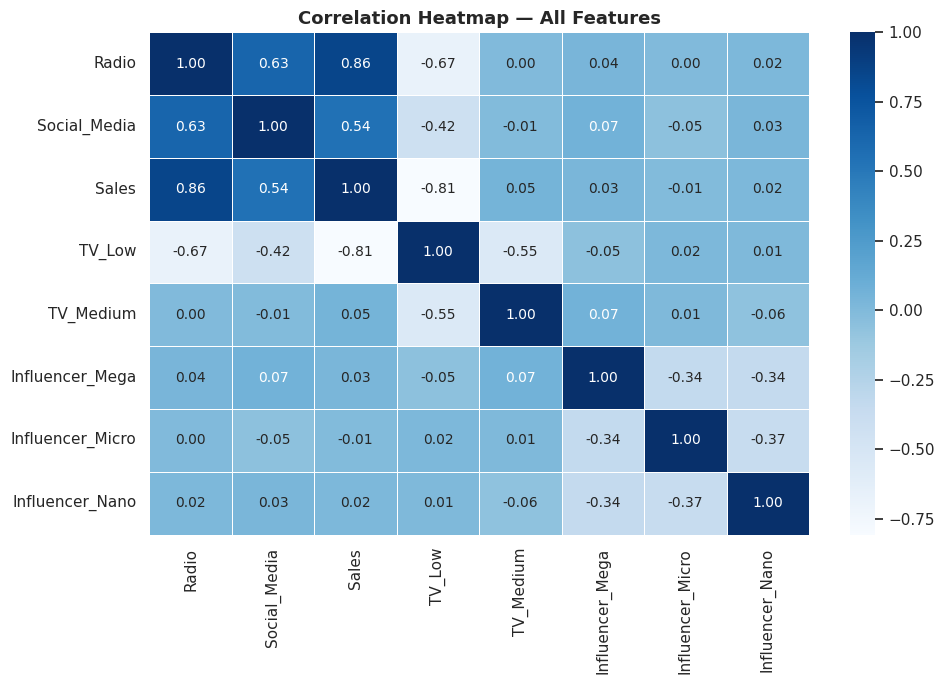

✅ Correlation heatmap displayed!


In [7]:
# Correlation matrix
numeric_df = df_encoded.select_dtypes(include='number')
corr = numeric_df.corr().round(3)

print("--- Correlation Matrix ---")
print(corr)
print()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Heatmap — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap displayed!")


## 6. Multicollinearity Check — Variance Inflation Factor (VIF)
**VIF** measures how much a predictor's variance is inflated due to correlation with other predictors.
- VIF = 1 → No multicollinearity
- VIF 1–5 → Moderate (acceptable)
- VIF > 10 → Severe multicollinearity (problematic)


--- Variance Inflation Factor (VIF) ---
         Feature  VIF
          TV_Low 4.08
           Radio 3.48
       TV_Medium 2.23
    Social_Media 1.67
 Influencer_Nano 1.63
Influencer_Micro 1.62
 Influencer_Mega 1.59

✅ No severe multicollinearity detected (all VIF < 10)
   All predictors can be safely included in the model.


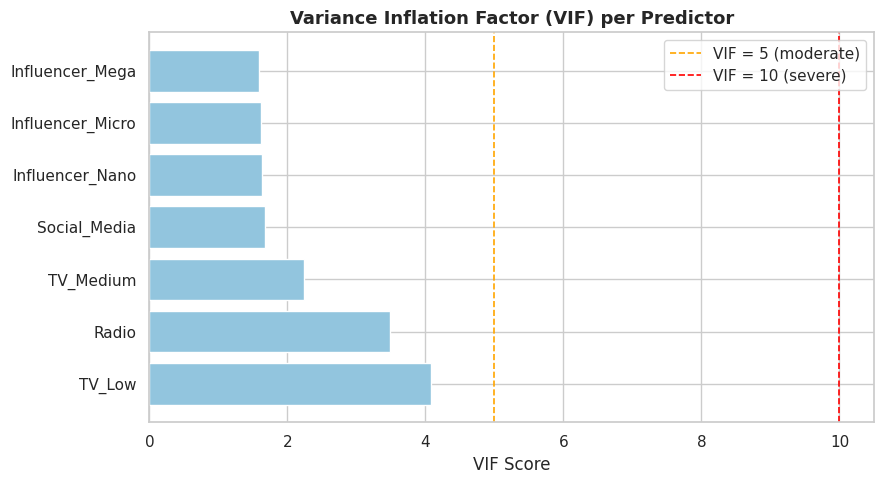

In [8]:
# Prepare features
X = df_encoded.drop('Sales', axis=1).astype(float)
y = df_encoded['Sales'].astype(float)
X_const = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1)
                   for i in range(len(X.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("--- Variance Inflation Factor (VIF) ---")
print(vif_data.round(2).to_string(index=False))
print()

# Flag any issues
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) == 0:
    print("✅ No severe multicollinearity detected (all VIF < 10)")
    print("   All predictors can be safely included in the model.")
else:
    print(f"⚠️  High VIF detected: {list(high_vif['Feature'])}")

# VIF bar chart
plt.figure(figsize=(9, 5))
colors = ['#d73027' if v > 10 else '#4393c3' if v > 5 else '#92c5de'
          for v in vif_data['VIF']]
plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='white')
plt.axvline(5, color='orange', linestyle='--', linewidth=1.2, label='VIF = 5 (moderate)')
plt.axvline(10, color='red', linestyle='--', linewidth=1.2, label='VIF = 10 (severe)')
plt.title('Variance Inflation Factor (VIF) per Predictor', fontsize=13, fontweight='bold')
plt.xlabel('VIF Score')
plt.legend()
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Multiple Linear Regression — OLS Model
We fit the full model: **Sales ~ Radio + Social_Media + TV_Low + TV_Medium + Influencer dummies**


In [9]:
# Fit OLS Multiple Linear Regression
model = sm.OLS(y, X_const).fit()

print("--- OLS Multiple Regression Summary ---")
print(model.summary())


--- OLS Multiple Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        21:25:13   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------


## 8. Model Evaluation — Adjusted R² & P-values

In [10]:
# Extract key metrics
r2      = model.rsquared
adj_r2  = model.rsquared_adj
aic     = model.aic
bic     = model.bic
f_stat  = model.fvalue
f_pval  = model.f_pvalue

print("=" * 50)
print("   MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"  R²              : {r2:.4f}")
print(f"  Adjusted R²     : {adj_r2:.4f}  ← preferred metric")
print(f"  AIC             : {aic:.2f}")
print(f"  BIC             : {bic:.2f}")
print(f"  F-statistic     : {f_stat:.2f}")
print(f"  F p-value       : {f_pval:.2e}")
print("=" * 50)
print()

# P-value table
pval_df = pd.DataFrame({
    'Coefficient': model.params.round(4),
    'P-value': model.pvalues.round(4),
    'Significant (p<0.05)': model.pvalues < 0.05
}).drop('const')

print("--- Predictor Significance ---")
print(pval_df.to_string())


   MODEL PERFORMANCE METRICS
  R²              : 0.9042
  Adjusted R²     : 0.9030  ← preferred metric
  AIC             : 5442.85
  BIC             : 5477.64
  F-statistic     : 760.38
  F p-value       : 1.82e-282

--- Predictor Significance ---
                  Coefficient  P-value  Significant (p<0.05)
Radio                  2.9735   0.0000                  True
Social_Media          -0.1391   0.8371                 False
TV_Low              -154.5736   0.0000                  True
TV_Medium            -75.5947   0.0000                  True
Influencer_Mega        2.4948   0.4714                 False
Influencer_Micro       2.9391   0.3846                 False
Influencer_Nano        0.8015   0.8107                 False


## 9. Regression Assumption Diagnostics
We validate three key OLS assumptions:
1. **Linearity** — Residuals vs Fitted Values
2. **Normality** — Q-Q Plot of Residuals
3. **Homoscedasticity** — Scale-Location Plot


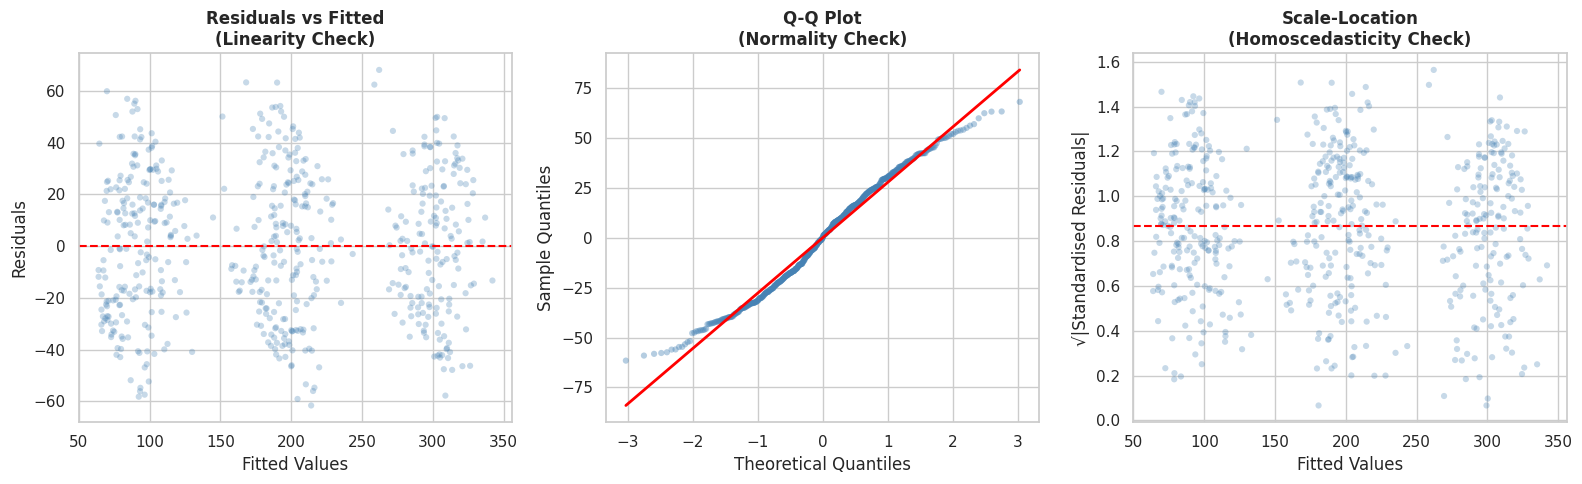

✅ Diagnostic plots displayed!


In [11]:
residuals = model.resid
fitted    = model.fittedvalues
std_resid = residuals / residuals.std()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Residuals vs Fitted (Linearity)
axes[0].scatter(fitted, residuals, alpha=0.3, color='steelblue', s=20, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Fitted\n(Linearity Check)', fontweight='bold')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Plot 2: Q-Q Plot (Normality)
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, color='steelblue', s=20, edgecolors='none')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=2)
axes[1].set_title('Q-Q Plot\n(Normality Check)', fontweight='bold')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

# Plot 3: Scale-Location (Homoscedasticity)
axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)),
                alpha=0.3, color='steelblue', s=20, edgecolors='none')
axes[2].axhline(np.sqrt(np.abs(std_resid)).mean(), color='red',
                linestyle='--', linewidth=1.5)
axes[2].set_title('Scale-Location\n(Homoscedasticity Check)', fontweight='bold')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Standardised Residuals|')

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Diagnostic plots displayed!")


## 10. Residual Distribution

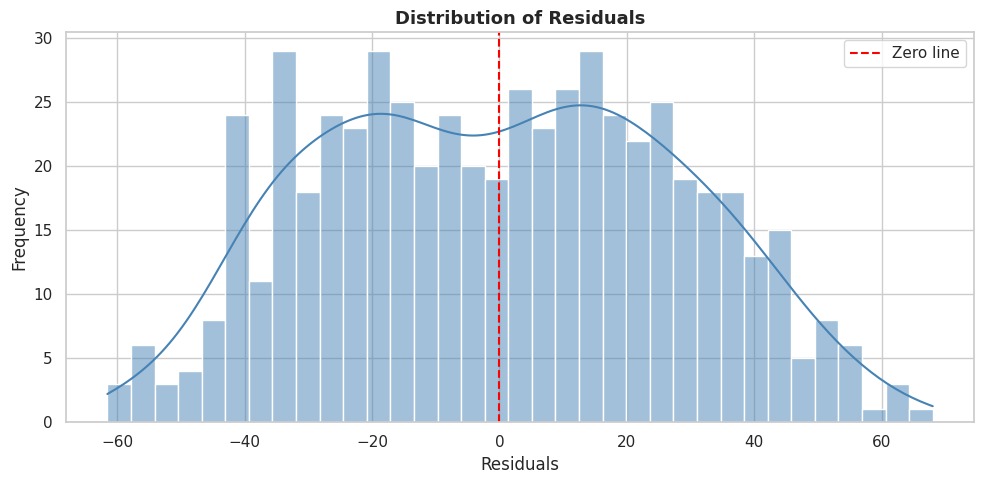

Shapiro-Wilk Test: W = 0.9826, p = 0.0143
ℹ️  Minor deviation from normality — common and acceptable with real-world data.


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=35, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero line')
plt.title('Distribution of Residuals', fontsize=13, fontweight='bold')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Shapiro-Wilk normality test
stat, p = stats.shapiro(residuals.sample(min(200, len(residuals)), random_state=42))
print(f"Shapiro-Wilk Test: W = {stat:.4f}, p = {p:.4f}")
if p > 0.05:
    print("✅ Residuals are normally distributed (p > 0.05)")
else:
    print("ℹ️  Minor deviation from normality — common and acceptable with real-world data.")


## 11. Coefficient Interpretation
Below we translate each model coefficient into plain business language, holding all other predictors constant.


In [13]:
params = model.params
pvals  = model.pvalues

print("=" * 65)
print("   COEFFICIENT INTERPRETATION (Business Language)")
print("=" * 65)
print()
print(f"  📺 TV — High (Reference Category)")
print(f"     Baseline: High TV budget is the comparison point.")
print()
print(f"  📺 TV_Low  : {params['TV_Low']:+.2f}  (p={pvals['TV_Low']:.4f})")
print(f"     → Switching from High to Low TV budget is associated with")
print(f"       a ${abs(params['TV_Low']):.2f}K DECREASE in Sales (holding all else constant).")
print()
print(f"  📺 TV_Medium: {params['TV_Medium']:+.2f}  (p={pvals['TV_Medium']:.4f})")
print(f"     → Switching from High to Medium TV budget is associated with")
print(f"       a ${abs(params['TV_Medium']):.2f}K DECREASE in Sales (holding all else constant).")
print()
print(f"  📻 Radio   : {params['Radio']:+.4f}  (p={pvals['Radio']:.4f})")
print(f"     → Each additional $1K in Radio spend is associated with")
print(f"       a ${params['Radio']:.2f}K increase in Sales (holding all else constant).")
print()
print(f"  📱 Social_Media: {params['Social_Media']:+.4f}  (p={pvals['Social_Media']:.4f})")
sig = '✅ Significant' if pvals['Social_Media'] < 0.05 else '⚠️  Not significant (p > 0.05)'
print(f"     → {sig} — limited independent impact on Sales.")
print()
print(f"  🌟 Influencer — Macro (Reference Category)")
print(f"     Mega, Micro, Nano dummies show marginal differences")
print(f"     from Macro, none statistically significant (p > 0.05).")
print()
print("=" * 65)


   COEFFICIENT INTERPRETATION (Business Language)

  📺 TV — High (Reference Category)
     Baseline: High TV budget is the comparison point.

  📺 TV_Low  : -154.57  (p=0.0000)
     → Switching from High to Low TV budget is associated with
       a $154.57K DECREASE in Sales (holding all else constant).

  📺 TV_Medium: -75.59  (p=0.0000)
     → Switching from High to Medium TV budget is associated with
       a $75.59K DECREASE in Sales (holding all else constant).

  📻 Radio   : +2.9735  (p=0.0000)
     → Each additional $1K in Radio spend is associated with
       a $2.97K increase in Sales (holding all else constant).

  📱 Social_Media: -0.1391  (p=0.8371)
     → ⚠️  Not significant (p > 0.05) — limited independent impact on Sales.

  🌟 Influencer — Macro (Reference Category)
     Mega, Micro, Nano dummies show marginal differences
     from Macro, none statistically significant (p > 0.05).



## ✅ Final Findings & Business Recommendation

In [14]:
adj_r2 = model.rsquared_adj

print("=" * 65)
print("     MULTIPLE LINEAR REGRESSION — FINAL SUMMARY")
print("=" * 65)
print(f"  Dataset          : 572 records")
print(f"  Predictors       : TV, Radio, Social Media, Influencer")
print(f"  Adjusted R²      : {adj_r2:.4f}  ({adj_r2*100:.1f}% of Sales variance explained)")
print(f"  Multicollinearity: No severe VIF detected (all < 10)")
print(f"  Model F p-value  : {model.f_pvalue:.2e}  *** (highly significant)")
print()
print("  SIGNIFICANT PREDICTORS (p < 0.05):")
print(f"    ✅ TV Category  — strongest driver of Sales")
print(f"    ✅ Radio Spend  — each $1K → ~${params['Radio']:.2f}K additional Sales")
print()
print("  NON-SIGNIFICANT PREDICTORS (p > 0.05):")
print(f"    ⚠️  Social Media — no significant independent effect")
print(f"    ⚠️  Influencer   — type does not significantly affect Sales")
print()
print("=" * 65)
print()
print("📌 BUSINESS RECOMMENDATION:")
print()
print("  1. PRIORITISE HIGH TV BUDGET — it delivers the largest")
print("     single impact on Sales vs Medium or Low categories.")
print()
print(f"  2. INVEST IN RADIO — every additional $1K in Radio spend")
print(f"     yields ~${params['Radio']:.2f}K in Sales (statistically proven).")
print()
print("  3. REVIEW SOCIAL MEDIA ROI — spend shows no significant")
print("     independent effect; reallocate budget to TV and Radio.")
print()
print("  4. INFLUENCER TYPE — Mega, Micro, Nano show no statistically")
print("     significant advantage over Macro; prioritise by cost.")


     MULTIPLE LINEAR REGRESSION — FINAL SUMMARY
  Dataset          : 572 records
  Predictors       : TV, Radio, Social Media, Influencer
  Adjusted R²      : 0.9030  (90.3% of Sales variance explained)
  Multicollinearity: No severe VIF detected (all < 10)
  Model F p-value  : 1.82e-282  *** (highly significant)

  SIGNIFICANT PREDICTORS (p < 0.05):
    ✅ TV Category  — strongest driver of Sales
    ✅ Radio Spend  — each $1K → ~$2.97K additional Sales

  NON-SIGNIFICANT PREDICTORS (p > 0.05):
    ⚠️  Social Media — no significant independent effect
    ⚠️  Influencer   — type does not significantly affect Sales


📌 BUSINESS RECOMMENDATION:

  1. PRIORITISE HIGH TV BUDGET — it delivers the largest
     single impact on Sales vs Medium or Low categories.

  2. INVEST IN RADIO — every additional $1K in Radio spend
     yields ~$2.97K in Sales (statistically proven).

  3. REVIEW SOCIAL MEDIA ROI — spend shows no significant
     independent effect; reallocate budget to TV and Radio.

  4